In [7]:
!pip install darts

In [8]:
# Data handling & plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Darts time series library
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.utils.timeseries_generation import linear_timeseries
from darts.utils.likelihood_models import GaussianLikelihood

# Scikit-learn for metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch

In [9]:
# Load the prepared daily dataset
DATA_PATH = "data/daily_dataset/daily_df_imputed.parquet"
df = pd.read_parquet(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4500000, 17)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,daily_sale_imputed,oos_hours_total,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.100000,0,1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.114286,3,1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.000000,6,1.0,1,0,2.0942,15.91,76.47,1.73
3,0,0,0,5,6,65,38,2024-03-31,0.218182,13,1.0,1,0,1.5618,16.13,77.40,1.76
4,0,0,0,5,6,65,38,2024-04-01,0.533333,15,1.0,0,0,3.5386,15.37,78.26,1.25


In [10]:
# Select category IDs to model
category_ids = [81, 65, 17]

# Build a dict of Darts TimeSeries for each category
series_dict = {}
for cat in category_ids:
    df_cat = (
        df[df['third_category_id']==cat]
          .groupby('dt', as_index=False)['daily_sale_imputed']
          .sum()
          .sort_values('dt')
    )
    # Convert to Darts TimeSeries, fill missing dates
    ts = TimeSeries.from_dataframe(
        df_cat,
        time_col='dt',
        value_cols='daily_sale_imputed',
        fill_missing_dates=True,
        freq='D'
    )
    series_dict[cat] = ts
    print(f"Category {cat}: series length = {len(ts)}")

Category 81: series length = 90
Category 65: series length = 90
Category 17: series length = 90


In [11]:
# 80/20 split for each series
train_series = {}
val_series = {}
for cat, ts in series_dict.items():
    cutoff = int(len(ts)*0.8)
    train_series[cat], val_series[cat] = ts[:cutoff], ts[cutoff:]
    print(f"Cat {cat}: train={len(train_series[cat])}, val={len(val_series[cat])}")

Cat 81: train=72, val=18
Cat 65: train=72, val=18
Cat 17: train=72, val=18


In [12]:
models = {}
for cat in category_ids:
    print(f"Training N-BEATS for category {cat}...")
    model = NBEATSModel(
    input_chunk_length=28,     # look back 28 days
    output_chunk_length=7,     # forecast 7 days ahead
    n_epochs=50,               # number of training epochs
    dropout=0.1,               # dropout in each layer
    batch_size=8,             # minibatch size
    random_state=42,           # reproducibility
    add_encoders={
        # cyclical encoding for day-of-week
        "cyclic": {
            "past":   ["dayofweek"],
            "future": ["dayofweek"],
        },
        # numeric month-of-year encoding
        "datetime_attribute": {
            "past":   ["month"],
            "future": ["month"],
        }
    },
    pl_trainer_kwargs={        # pass through to PyTorch Lightning
        "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
        "devices": 1,
    }
)
    model.fit(
        series=train_series[cat],
        past_covariates=None,
        future_covariates=None,
        verbose=True
    )
    models[cat] = model

Specified future encoders in `add_encoders` at model creation but model does not accept future covariates. future encoders will be ignored.


Training N-BEATS for category 81...


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(

  | Name            | Type             | Params
-----------------------------------------------------
0 | criterion       | MSELoss          | 0     
1 | train_criterion | MSELoss          | 0     
2 | val_criterion   | MSELoss          | 0     
3 | train_metrics   | MetricCollection | 0     
4 | val_metrics     | MetricCollection | 0     
5 | stacks          | ModuleList       | 6.9 M 
-----------------------------------------------------
6.9 M     Trainable params
2.0 K     Non-trainable params
6.9 M     Total params
55.131    Total estimated model p

Epoch 0:   0%|          | 0/5 [00:00<?, ?it/s] 

/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/torch/__init__.py:1240: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


...

Epoch 0:  20%|██        | 1/5 [00:00<00:00, 13.36it/s, loss=1.17e+05, train_loss=1.17e+5]

/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 49: 100%|██████████| 5/5 [00:00<00:00, 20.91it/s, loss=508, train_loss=290.0]       

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 5/5 [00:00<00:00, 20.81it/s, loss=508, train_loss=290.0]


In [13]:
forecasts = {}
metrics = {}
for cat in category_ids:
    model = models[cat]
    val_ts = val_series[cat]
    # Make a forecast of same length as validation
    pred = model.predict(len(val_ts))
    forecasts[cat] = pred
    # Calculate metrics
    mae = mean_absolute_error(val_ts.values(), pred.values())
    rmse = np.sqrt(mean_squared_error(val_ts.values(), pred.values()))
    metrics[cat] = {'MAE': mae, 'RMSE': rmse}
    print(f"Category {cat} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 14.38it/s]
Category 81 → MAE: 1614.36, RMSE: 1959.47


/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Tra

Predicting DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs



Category 65 → MAE: 807.95, RMSE: 876.24


/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 77.11it/s]
Category 17 → MAE: 76.15, RMSE: 89.91


/Users/jhilmitasri/Repositories/MyRepositories/freshretail-demand-forecasting/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


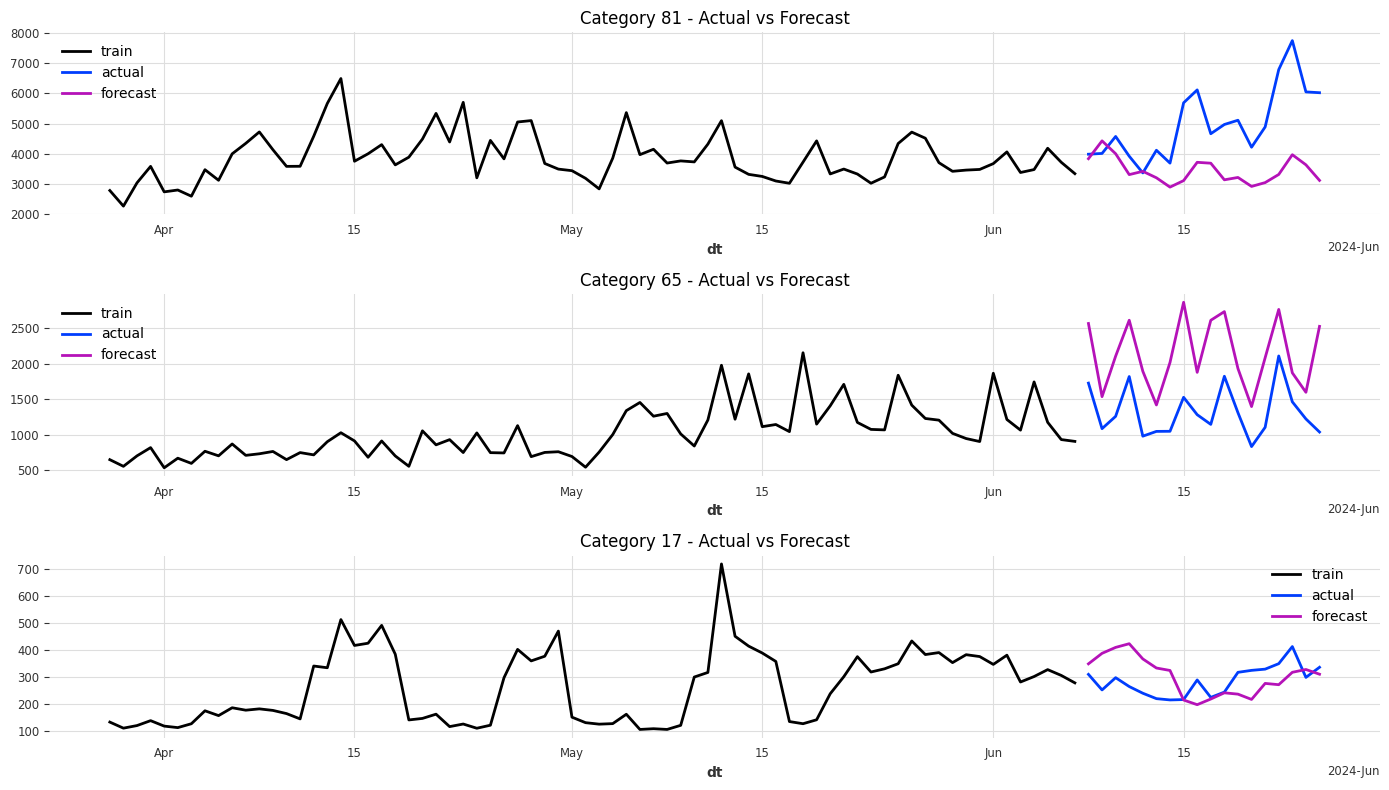

In [14]:
plt.figure(figsize=(14, 8))
for i, cat in enumerate(category_ids, 1):
    plt.subplot(len(category_ids), 1, i)
    train_series[cat].plot(label='train')
    val_series[cat].plot(label='actual')
    forecasts[cat].plot(label='forecast')
    plt.title(f"Category {cat} - Actual vs Forecast")
    if i == 1:
        plt.legend()
plt.tight_layout()
plt.show()